In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib Inline
%config IlineBackend.figure_format = "svg"

**Построение модели классификации**
1. Обзор обучающего датасета
2. Обработка выбросов
3. Обработка пропусков
4. Анализ данных
5. Отбор признаков
6. Подбор моделей, получение бейзлана
7. Проверка качества, борьба с переобучением
8. Интерпретация результатов

In [173]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

## 1. EDA (Exploratory Data Analysis)

### 1.1 Target variable and base statistics

In [41]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  float64
 1   years_of_experience  10000 non-null  float64
 2   lesson_price         10000 non-null  float64
 3   qualification        10000 non-null  float64
 4   physics              10000 non-null  float64
 5   chemistry            10000 non-null  float64
 6   biology              10000 non-null  float64
 7   english              10000 non-null  float64
 8   geography            10000 non-null  float64
 9   history              10000 non-null  float64
 10  mean_exam_points     10000 non-null  float64
 11  choose               10000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 937.6 KB


* **Id** - unique identifier
* **age** - Age of tutor
* **years_of_experience**
* **lesson_price**
* **qualification**
* **physics** - teaches physics
* **chemistry** - teaches chemistry
* **biology** - teaches biology
* **english** - teaches english
* **geography** - teaches geography
* **history** - teaches history
* **mean_exam_points**
* **choose** - target

In [42]:
df_train.describe()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,45.800900,1.974800,1702.440000,1.724300,0.37060,0.121500,0.117200,0.059100,0.02770,0.018000,64.435200,0.110900
std,8.030274,1.766883,523.789062,0.798845,0.48299,0.326724,0.321675,0.235824,0.16412,0.132958,13.595024,0.314024
min,23.000000,0.000000,200.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,33.000000,0.000000
25%,40.000000,0.000000,1300.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,55.000000,0.000000
50%,46.000000,2.000000,1550.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,63.000000,0.000000
75%,51.000000,3.000000,2150.000000,2.000000,1.00000,0.000000,0.000000,0.000000,0.00000,0.000000,74.000000,0.000000
max,68.000000,9.000000,3950.000000,4.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,100.000000,1.000000


At first sight everything is clear. There are no Null elements in features, min and max values apear to be right (no outliers in the data). There are only two types of data. First is int64 type float64. Should think about reducing memory usage.


Continue investigate the data.

In [43]:
df_train.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
0,35.0,0.0,2150.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,74.0,0
1,52.0,2.0,1250.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,57.0,1
2,29.0,3.0,1750.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,66.0,0
3,33.0,3.0,1050.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,66.0,1
4,46.0,3.0,2250.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,73.0,0


In [44]:
df_test.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
0,32.0,2.0,2700.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0
1,35.0,6.0,1800.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,71.0
2,44.0,2.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
3,44.0,4.0,2950.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,92.0
4,38.0,3.0,1400.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,58.0


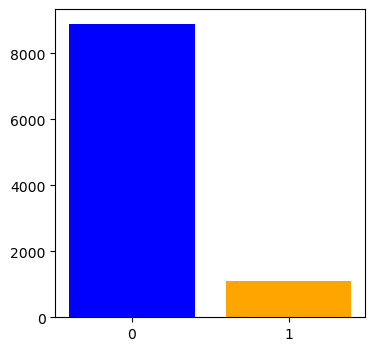

In [155]:
plt.figure(figsize=(4, 4))

target_data = df_train["choose"].value_counts()

plt.bar(target_data.index, target_data.values, color=["blue", "orange"])
plt.xticks(ticks=[0, 1])

plt.show()

There is a big disbalance in the target variable

In [174]:
# Field ID is not informative, let's get rid of it
df_train.drop("Id", axis=1, inplace=True)
df_test.drop("Id", axis=1, inplace=True)

## Continuous variables

In [8]:
# Function for calculating
def measures_of_the_central_trend(data: pd.Series):
    mean_ = data.mean()
    median_ = data.median()
    mode_ = data.mode()[0]
    return mean_, median_, mode_

### Age

In [9]:
age_mean, age_median, age_mode = measures_of_the_central_trend(df_train["age"])
print(f"Measures of the central trend for Age:\nMean - {age_mean}\nMode - {age_mode}\nMedian - {age_median}")

Measures of the central trend for Age:
Mean - 45.8009
Mode - 44.0
Median - 46.0


<Figure size 300x300 with 0 Axes>

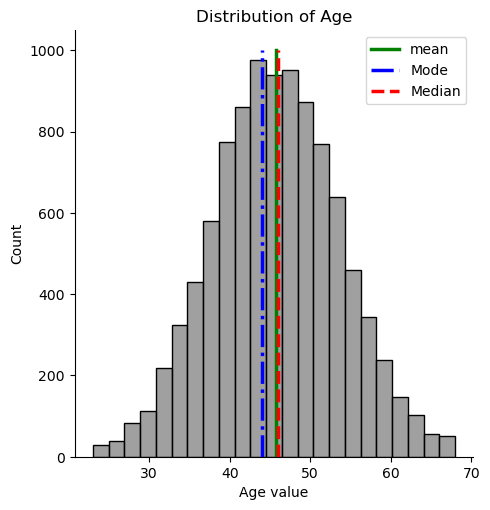

In [10]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1000, 1000)
sns.displot(df_train["age"], bins=23, color="grey", kde=False)
plt.plot([age_mean] * 1000, y, color="green", linewidth=2.5, label="mean")
plt.plot([age_mode] * 1000, y, color="blue", linewidth=2.5, label="Mode", linestyle="-.")
plt.plot([age_median] * 1000, y, color="red", linewidth=2.5, label="Median", linestyle="dashed")

plt.title("Distribution of Age")
plt.ylabel("Count")
plt.xlabel("Age value")
plt.legend(loc="upper right")

plt.show()

### Lesson price

In [11]:
lesson_price_mean, lesson_price_median, lesson_price_mode = measures_of_the_central_trend(df_train["lesson_price"])
print(f"Measures of the central trend for lesson_price:\nMean - {lesson_price_mean}\nMode - {lesson_price_mode}\nMedian - {lesson_price_median}")

Measures of the central trend for lesson_price:
Mean - 1702.44
Mode - 1450.0
Median - 1550.0


<Figure size 300x300 with 0 Axes>

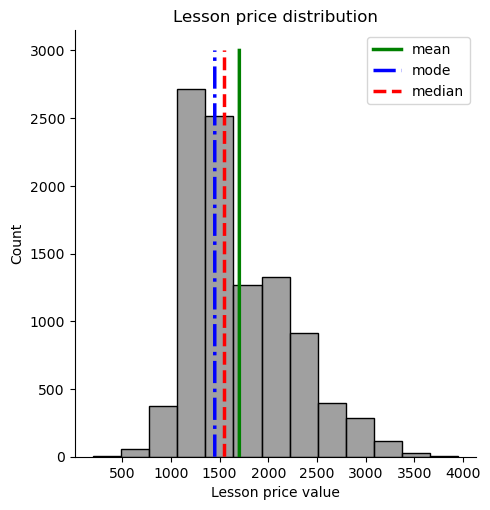

In [12]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 3000, 3000)
sns.displot(df_train["lesson_price"], bins=13, color="grey", kde=False)
plt.plot([lesson_price_mean] * 3000, y, color="green", linewidth=2.5, label="mean")
plt.plot([lesson_price_mode] * 3000, y, color="blue", linewidth=2.5, linestyle="-.", label="mode")
plt.plot([lesson_price_median] * 3000, y, color="red", linewidth=2.5, linestyle="dashed", label="median")

plt.title("Lesson price distribution")
plt.ylabel("Count")
plt.xlabel("Lesson price value")
plt.legend(loc="upper right")

plt.show()

### Mean exam points

In [13]:
mean_exam_points_mean, mean_exam_points_median, mean_exam_points_mode = measures_of_the_central_trend(df_train["mean_exam_points"])
print(
    f"Measures of the central trend for mean_exam_points_:\nMean - {mean_exam_points_mean}\nMode - {mean_exam_points_mode}\nMedian - "\
    f"{mean_exam_points_median}"
)

Measures of the central trend for mean_exam_points_:
Mean - 64.4352
Mode - 62.0
Median - 63.0


<Figure size 300x300 with 0 Axes>

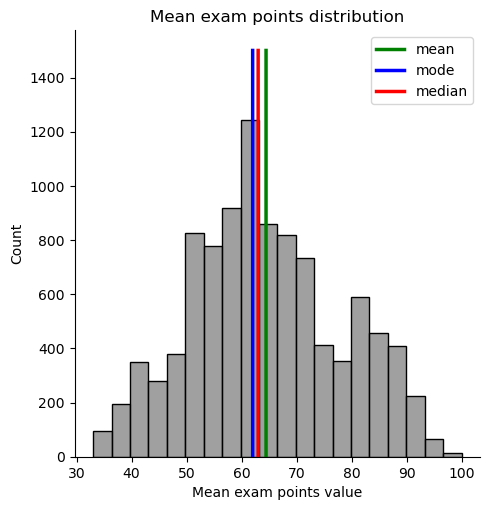

In [14]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["mean_exam_points"], bins=20, color="grey", kde=False)
plt.plot([mean_exam_points_mean] * 1500, y, color="green", linewidth=2.5, label="mean")
plt.plot([mean_exam_points_mode] * 1500, y, color="blue", linewidth=2.5, label="mode")
plt.plot([mean_exam_points_median] * 1500, y, color="red", linewidth=2.5, label="median")

plt.title("Mean exam points distribution")
plt.ylabel("Count")
plt.xlabel("Mean exam points value")
plt.legend(loc="upper right")

plt.show()

According to the histogram, Age and Mean exam points distributions tend to be normal, at the same time Lesson prise distribution has Asymmetrically type of distribution. Max point of exam do not exceed 100 and min point value is above zero.

The Age of Majority's tutors placed between 40 and 50. Mode and mean values are almost identical 44.0, 45.8 respectively, therefore this distribution realy tends to be normal.

Measures of the central trend for Mean exam points are quite close to each other (62, 63, 64.4)

The most popular Lesson prices located between 1100 and 1500. The biggest price is 4000, the smallest is 200. So now, this data is apears to be clear

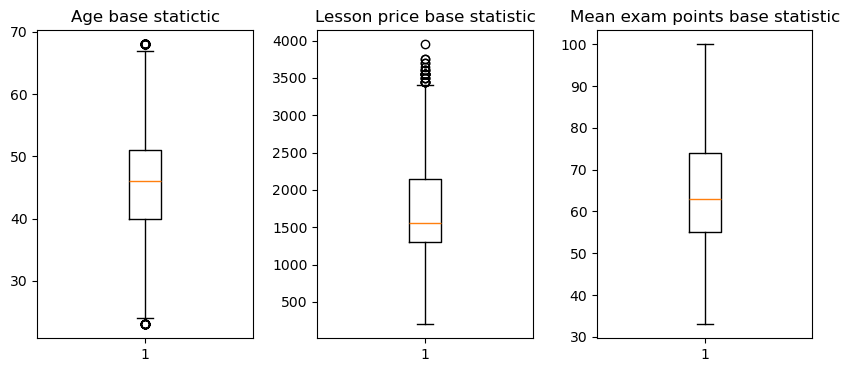

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

ax1, ax2, ax3 = axes.flatten()

ax1.boxplot(df_train["age"])
ax1.set_title("Age base statictic")

ax2.boxplot(df_train["lesson_price"])
ax2.set_title("Lesson price base statistic")

ax3.boxplot(df_train["mean_exam_points"])
ax3.set_title("Mean exam points base statistic")

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

According to these base statistic figures Age and Lesson price have outliers. Calculate quantlies and IQR.

In [148]:
# Function for calculating quartiles
def culculate_quantiles(data: pd.Series):
    q1 = data.quantile(.25)
    q3 = data.quantile(.75)
    iqr = q3 - q1
    return q1, q3, iqr

In [17]:
age_q1, age_q3, age_iqr = culculate_quantiles(df_train["age"])
print(f"Age Q1 - {age_q1}, Q3 - {age_q3}, IQR - {age_iqr}")
outliers_age = df_train.loc[(df_train["age"] > age_q3 + 1.5 * age_iqr) | (df_train["age"] < age_q1 - age_iqr * 1.5), :]

Age Q1 - 40.0, Q3 - 51.0, IQR - 11.0


In [18]:
outliers_age.sort_values(by=["age", "choose"], ascending=True)

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
89,23.0,1.0,2150.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,83.0,0
144,23.0,0.0,1400.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0,0
251,23.0,1.0,1100.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,65.0,0
1754,23.0,0.0,2700.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,82.0,0
2035,23.0,1.0,1500.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,51.0,0
2375,23.0,1.0,2600.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0,0
2460,23.0,5.0,2300.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0,0
2652,23.0,1.0,1450.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,0
2718,23.0,2.0,2350.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,65.0,0
4456,23.0,2.0,2800.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,87.0,0


In [19]:
lesson_price_q1, lesson_price_q3, lesson_price_iqr = culculate_quantiles(df_train["lesson_price"])
print(f"Lesson price Q1 - {lesson_price_q1}, Q3 - {lesson_price_q3}, IQR - {lesson_price_iqr}")
outliers_lesson_price = df_train.loc[
    (df_train["lesson_price"] > lesson_price_q3 + 1.5 * lesson_price_iqr) | (df_train["lesson_price"] < lesson_price_q1 - lesson_price_iqr * 1.5), :
    ]

Lesson price Q1 - 1300.0, Q3 - 2150.0, IQR - 850.0


In [20]:
outliers_lesson_price.sort_values(by=["lesson_price", "choose"])

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
157,59.0,7.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,95.0,0
1863,55.0,6.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,85.0,0
1934,56.0,6.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,87.0,0
2522,50.0,5.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,93.0,0
9015,49.0,5.0,3450.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0,0
865,58.0,6.0,3500.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,0
1003,52.0,6.0,3500.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,91.0,0
3327,62.0,7.0,3500.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0,0
132,62.0,7.0,3550.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0,0
1087,51.0,5.0,3550.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,85.0,0


No one tutors were chosen who have price above Q3 + IQR and less Q1 - IQR. As regards age, there is only one tutor chosen, who was younger than Q1 - IQR and 4 tutors older Q3 + IQR

**Maybe I should create new feature "Lesson price" with outliers pointing model, that too big and too small price is not right way to choose tutor.**

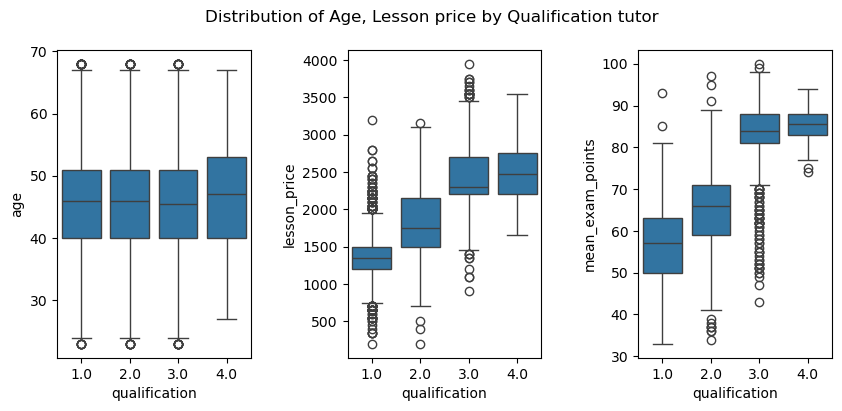

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

fig.suptitle("Distribution of Age, Lesson price by Qualification tutor")

sns.boxplot(data=df_train, x="qualification", y="age", ax=axes[0])
sns.boxplot(data=df_train, x="qualification", y="lesson_price", ax=axes[1])

sns.boxplot(data=df_train, x="qualification", y="mean_exam_points", ax=axes[2])

plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

The average age is higher for tutors of 4 qualification. The same trend displayed for lesson price and mean exam points. Lesson price, mean exam points tutors of 4 qualification much more than the same rates of tutors smaller qualification. At the same time there are a lot of students have points less than 70 who had been tought by tutor of 3 qualification

<Figure size 200x200 with 0 Axes>

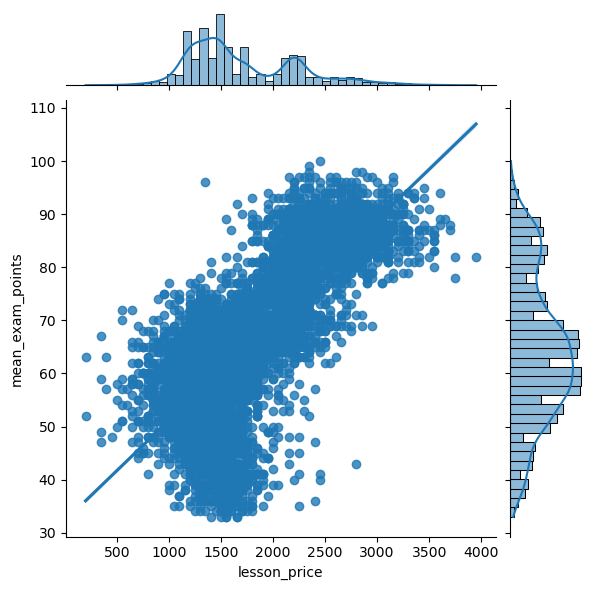

In [22]:
plt.figure(figsize=(2, 2))

sns.jointplot(data=df_train, x="lesson_price", y="mean_exam_points", kind="reg")

plt.show()

As the prices rice so do mean exam points.

## Categorical variables

In [23]:
chosen = df_train.loc[df_train["choose"] == 1, "choose"].count()
not_chosen = df_train.loc[df_train["choose"] == 0, "choose"].count()
print(f"Number of chosen - {chosen}, number of not chosen - {not_chosen}")

Number of chosen - 1109, number of not chosen - 8891


In [72]:
category = ["physics", "chemistry", "biology", "english", "geography", "history"]

In [25]:
df_train_cat = df_train[category].apply(lambda x: x.sum(), axis=0)

In [26]:
df_train_cat["no_subjects"] = df_train[category].apply(lambda x: sum([1 if i == 0 else 0 for i in x]) == 6, axis=1).sum()

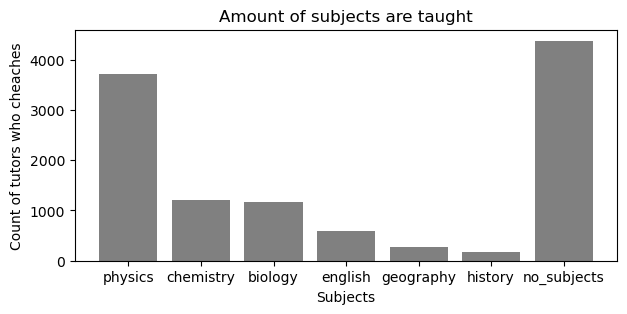

In [27]:
plt.figure(figsize=(7, 3))

plt.bar(df_train_cat.index, df_train_cat, color="grey")
plt.title("Amount of subjects are taught")
plt.xlabel("Subjects")
plt.ylabel("Count of tutors who cheaches")

plt.show()

The most popular subject is physics - above 3500, unpopular is history - less 500. Chemistry and biology are located almost at the same level - 1200. But the biggest number tutors is tutors who do not have subjects (more than 4300)

In [28]:
choose_by_qualification = df_train.groupby(by="qualification").agg({"choose": "sum"})
choose_by_qualification

,choose
qualification,
1.0,504
2.0,317
3.0,272
4.0,16


Majority of students chose tutor of 1 qualification - 504 tuturs. Tutors with forth qualification ternd out to be the most unpopular

In [29]:
chosen_tutor_by_physics_and_chemistry = pd.pivot_table(
    data=df_train, columns=["physics"], values="choose", aggfunc="sum"
)
chosen_tutor_by_physics_and_chemistry

physics,0.0,1.0
choose,402,707


Tutors teach physics (707) (and were chosen) is the biggest portion of all chosen (1109).

In [30]:
exp = pd.pivot_table(
    data=df_train, columns=["biology", "history"], values="choose", aggfunc="sum"
)
exp

biology  0.0      1.0    
history  0.0 1.0  0.0 1.0
choose   895  12  196   6

In [31]:
exp = pd.pivot_table(
    data=df_train, index="qualification", columns=["biology", "history","geography"], values="choose", aggfunc="sum"
)
exp

biology          0.0                   1.0          
history          0.0        1.0        0.0       1.0
geography        0.0   1.0  0.0  1.0   0.0  1.0  0.0
qualification                                       
1.0            389.0  14.0  6.0  0.0  90.0  3.0  2.0
2.0            253.0   7.0  4.0  NaN  49.0  2.0  2.0
3.0            210.0   7.0  2.0  0.0  50.0  1.0  2.0
4.0             15.0   0.0  0.0  NaN   1.0  0.0  NaN

Between all subjects intresting observations were found:
- Student preferd tutors who do not teach biology, history and geography (867)
- Tutors with physics were preferable (707)

But should take into account that this information does not include information about other feature

**Let's try to figure out what can be deeper in this combination: biology, history and geography**

In [145]:
no_biology_no_history_no_geography = df_train.loc[
    (df_train["biology"] == 0) & 
    (df_train["history"] == 0) & 
    (df_train["choose"] == 1) & 
    (df_train["geography"] == 0), :
    ]
# no_biology_no_history.loc[(no_biology_no_history["lesson_price"] < 2200) & (no_biology_no_history["qualification"] == 1)]

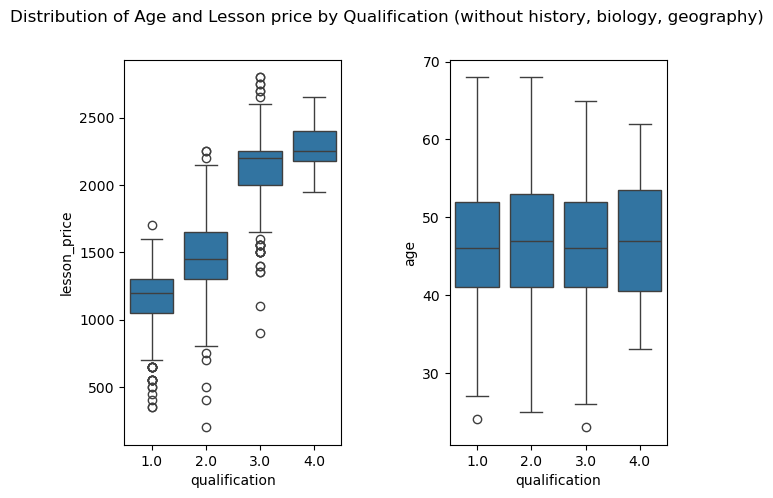

In [146]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 5))

fig.suptitle("Distribution of Age and Lesson price by Qualification (without history, biology, geography)")

sns.boxplot(ax=axes[0], data=no_biology_no_history_no_geography, x="qualification", y="lesson_price")
sns.boxplot(ax=axes[1], data=no_biology_no_history_no_geography, x="qualification", y="age")

plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

As we can see, the bigger qualification the higher lesson price. There is no big difference in mean age of tutors different qualification, but variance is getting less closer to 4 qualification.

In [149]:
n_his_n_bio_n_geo_q1, n_his_n_bio_n_geo_q3, n_his_n_bio_n_geo_iqr = culculate_quantiles(no_biology_no_history_no_geography["lesson_price"])
print(
    f"Quartiles for Lesson price (biology, history, geography) Q1 - {n_his_n_bio_n_geo_q1}, Q3 - {n_his_n_bio_n_geo_q3}, IQR {n_his_n_bio_n_geo_iqr}"
)

Quartiles for Lesson price (biology, history, geography) Q1 - 1200.0, Q3 - 1750.0, IQR 550.0


In [150]:
hbg_outliers_down = n_his_n_bio_n_geo_q1 - 1.5 * n_his_n_bio_n_geo_iqr
hbg_outliers_up = n_his_n_bio_n_geo_q3 + 1.5 * n_his_n_bio_n_geo_iqr
hbg_outliers_down, hbg_outliers_up

(np.float64(375.0), np.float64(2575.0))

In [151]:
amount_bhg_without_outliers = no_biology_no_history_no_geography.loc[
    (no_biology_no_history_no_geography["lesson_price"] > hbg_outliers_down) & (no_biology_no_history_no_geography["lesson_price"] < hbg_outliers_up)
    ].shape[0]
print(f"Amount of tutors (no history, biology, geography) with too big and too small lesson price - {no_biology_no_history_no_geography.shape[0]}." \
      f" Without outliers in price {amount_bhg_without_outliers}"
     )

Amount of tutors (no history, biology, geography) with too big and too small lesson price - 867. Without outliers in price 855


Lesson price outliers reducing showed negative outcome. Amount of tutors with outliers bigger than without.

**Trying to make combination with biology, history, geography and physics**

In [37]:
pd.pivot_table(data=df_train, index="choose", values="physics", aggfunc="sum", columns=["biology", "history", "geography"])

biology       0.0                     1.0          
history       0.0         1.0         0.0       1.0
geography     0.0   1.0   0.0  1.0    0.0  1.0  0.0
choose                                             
0          2566.0  75.0  51.0  0.0  303.0  2.0  2.0
1           568.0  12.0  11.0  NaN  112.0  1.0  3.0

In [38]:
pd.pivot_table(
    data=df_train, columns=["biology", "history", "physics"], values="choose", aggfunc="sum"
)

biology  0.0              1.0             
history  0.0      1.0     0.0      1.0    
physics  0.0  1.0 0.0 1.0 0.0  1.0 0.0 1.0
choose   315  580   1  11  83  113   3   3

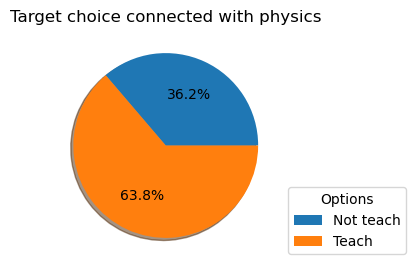

In [39]:
plt.figure(figsize=(3, 3))

plt.pie(
    x=df_train.groupby(by=["physics"]).agg({"choose": "sum"})["choose"],
    autopct='%1.1f%%',
    shadow=True
)

plt.title("Target choice connected with physics")
plt.legend(
title="Options",
loc="lower left",
bbox_to_anchor=(1, 0, 0.5, 1),
labels=["Not teach", "Teach"]
)


plt.show()

The total number of tutors who teach physics is 3706. The amount of tuturs who have been chosen is 707. Of these 568 do not teach history, biology, and geography. This number is almost 81% of chosen tutors connected with physics.

- From the one hand almost all chosen physics tutors are represented by combination: no history, biology, and geography but physics.
- But on the other hand the same combination gives outcome of 2566 tutors who were not chosen

In order to predict the right tutors connected with physics we can consider this as a new feature

In [76]:
category

['physics', 'chemistry', 'biology', 'english', 'geography', 'history']

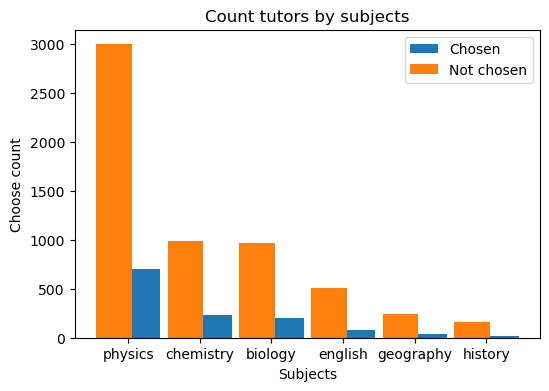

In [144]:
plt.figure(figsize=(6, 4))

xpos = np.arange(len(category))

plt.bar(xpos + 0.2, df_train.loc[df_train["choose"] == 1, category].sum().values, label="Chosen", width=0.5)
plt.bar(xpos - 0.2, df_train.loc[df_train["choose"] == 0, category].sum().values, label="Not chosen", width=0.5)

plt.xticks(ticks=xpos, labels=category)
plt.xlabel("Subjects")
plt.ylabel("Choose count")
plt.title("Count tutors by subjects")
plt.legend(loc="upper right")

plt.show()

A little percent of chosen tutors who teach their subject exists in all category. This value is quite small, especially in history, geography and english.

In [152]:
# History
pd.pivot_table(data=df_train, values="choose", aggfunc="sum", columns="history")

history,0.0,1.0
choose,1091,18


The total number of tutors with history - 180. Of these 18 have been chosen -> therefore tutor with history has the big chances not to be chosen

In [43]:
no_subjects_idx = df_train[category].apply(lambda x: sum([1 if i == 0 else 0 for i in x]) == 6, axis=1)
not_sub = df_train[no_subjects_idx]
not_sub_chosen = not_sub.loc[not_sub["choose"] == 1].shape[0]
print(
    f"The total number tutors who do not teach any subjects - {not_sub.shape[0]}. " \
    f"Of these {not_sub_chosen} were chosen and {not_sub.shape[0] - not_sub_chosen} were not chosen"
)

The total number tutors who do not teach any subjects - 4381. Of these 207 were chosen and 4174 were not chosen


There is big possibility for tutor who does not teach any subjucts not to be chosen

## Baseline model

### Logistic Regression

In [164]:
class MyLogisticRegression:

    def __init__(self, iterations, eta, random_state=None):
        self.iterations = iterations
        self.eta = eta
        self.rng_model = np.random.RandomState(random_state)
        self.min_weight_dist = 1e-4
        self.errors = []
        # self.weights = []
        self.weights = None
        self.final_error = 0

    # Function for converting predicted values to form from 0 to 1
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Logloss. Function for model to learn
    def logloss(self, y, y_pred):
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = - np.mean(y * np.log(y_pred) + (1.0 - y) * np.log(1.0 - y_pred))

        return loss

    # Function for teaching and evaluating the model
    def eval_model(self, X, y):
        W = self.rng_model.randn(X.shape[1])
        n = X.shape[0]
        # self.weights.append(W)

        for i in range(self.iterations):
            z = np.dot(X, W)
            y_pred = self.sigmoid(z)

            err = self.logloss(y, y_pred)
            self.errors.append(err)

            dQ = 1 / n * X.T @ (y_pred - y)
            
            next_w = W - dQ * self.eta

            if np.linalg.norm(W - next_w) < self.min_weight_dist:
                W = next_w
                break
            
            W = next_w

            # self.weights.append(W)

            # if i % (iterations / 10) == 0:
            #     print(i, W, err)

        self.weights = W
        self.final_error = err

    # Function for predictions
    def calc_prediction(self, X):
        if self.weights is None:
            raise ValueError("You did not fit model")
        probabilities = self.sigmoid(np.dot(X, self.weights))
        threshold = 0.5 #np.mean(probabilities)
        predictions = np.where(probabilities > threshold, 1, 0)
        print("Min possibility:", np.min(probabilities))
        print("Max possibility:", np.max(probabilities))
        print("Mean possibility:", np.mean(probabilities))
        print("Current weights:", self.weights)
        return predictions, probabilities

### Write Standard Scaler

In [6]:
class MyStandardScaler:
    """
    So now MyStandardScaler transforms next features: "age", "years_of_experience", "lesson_price", "qualification", "mean_exam_points"
    OR [0, 1, 2, 3, 10]
    Should think about making exeption for qualification or transform it to one-hot
    """

    def __init__(self):
        self.fitted_values = {}
        self.columns_to_scale = [0, 1, 2, 3, 10]

    def fit(self, arr):
        for col in self.columns_to_scale:
            x_mean = np.mean(arr[:, col])
            x_std = np.std(arr[:, col])
            self.fitted_values[col] = {"mean": x_mean, "std": x_std}
        return self
        
    def transform(self, arr):
        if not self.fitted_values:
            raise ValueError("You did not fit scaler. First, use method fit")
        scaled_arr = arr.copy().astype(np.float64)
        for col in self.columns_to_scale:
            mean = self.fitted_values[col]["mean"]
            std = self.fitted_values[col]["std"]

            scaled_arr[:, col] = (scaled_arr[:, col] - mean) / (std)# + 1e-8)
        return scaled_arr

### Function for splitting data on test and train

In [161]:
def split_test_train(X, y, proportion, random_state=None):
    """
    Firstly divide the ratio of 60 by 40 for train and test. Then divide test data in the ratio of 20 by 20.
    Eventually we have 3 data arrays: train, validation, test
    And try to make the same target portions in all arrays (Stratification)

    proportion - percent for splitting, format - float (0.6)
    """
    y.reset_index(drop=True, inplace=True)
    rng_split = np.random.RandomState(random_state)
    
    idx_1 = np.where(y == 1)[0]
    idx_0 = np.where(y == 0)[0]

    rng_split.shuffle(idx_1)
    rng_split.shuffle(idx_0)

    portion_1 = int(np.round(idx_1.shape[0] * proportion))
    portion_0 = int(np.round(idx_0.shape[0] * proportion))

    train_idx = np.concat([idx_1[: portion_1], idx_0[: portion_0]])
    test_idx = np.concat([idx_1[portion_1: ], idx_0[portion_0: ]])

    rng_split.shuffle(train_idx)
    rng_split.shuffle(test_idx)

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    return X_train, X_test, y_train, y_test

In [166]:
# function for searching best parametrs
def find_best_parameters(X_train, y_train, X_valid, y_valid):
    results = []
    etas = [0.0001, 0.001, 0.01, 0.05, 0.1]
    n_iters = [1000, 2000, 5000, 7000]

    best_score = -1
    best_model = None
    best_params = {}

    for eta in etas:
        for n_iter in n_iters:
            lr = MyLogisticRegression(iterations=n_iter, eta=eta, random_state=42)

            scaler = MyStandardScaler()
            scaler.fit(X_train)
            X_train_scaled = scaler.transform(X_train)
            X_valid_scaled = scaler.transform(X_valid)
            
            lr.eval_model(X_train_scaled, y_train)
            
            predictions, probabilities = lr.calc_prediction(X_valid_scaled)

            evaluator = EvaluateModel(y_pred=predictions, y_pred_proba=probabilities, y=y_valid)

            roc_auc, pr_auc = evaluator.evaluation()
                        
            current_result = {
                "eta": eta,
                "n_iter": n_iter,
                "roc_auc": roc_auc,
                "pr_auc": pr_auc,
                "errors": lr.errors,
                "weights": lr.weights,
                "scaler": scaler
            }
            result.append(current_result)

            print(f"eta={eta:.4f}, n_iter={n_iter}: ROC-AUC={roc_auc:.4f}, PR-A={pr_auc:.4f}")

            if pr_auc > best_score:
                best_score = pr_auc
                best_model = lr
                best_params = {"eta": eta, "n_iter": n_iter, "scaler": scaler}

    stored_results = sorted(results, key=lambda x: x["pr_auc"], reverse=True)

    return results_sorted, best_model, best_params

In [206]:
class EvaluateModel:

    def __init__(self, y_pred, y_pred_proba, y):
        self.y_predictions = y_pred
        self.y_predictions_probability = y_pred_proba
        self.y_target = y
        self.confusion_matrix = None
        self.precision = None
        self.recall = None
        self.accuracy = None
        self.tpr = None
        self.fpr = None
        self.auc_roc_score = None
        self.auc_pr_score = None

    def evaluation(self):
        self.calc_confusion_matrix()
        self.calc_metrix_from_confusion_matrix()

        ROC_AUC = self.calc_roc_auc()
        PR_AUC = self.calc_pr_roc_auc()
        
        return ROC_AUC, PR_AUC

    def calc_confusion_matrix(self):
        eps = 1e-8
        
        true_negative = np.sum((self.y_predictions == 0) & (self.y_target == 0))
        false_positive = np.sum((self.y_predictions == 1) & (self.y_target == 0))
        false_negative = np.sum((self.y_predictions == 0) & (self.y_target == 1))
        true_positive = np.sum((self.y_predictions == 1) & (self.y_target == 1))
    
        self.confusion_matrix = np.array([
            [true_positive, false_positive],
            [false_negative, true_negative]
        ])
    
        #return self.confusion_matrix

    def calc_metrix_from_confusion_matrix(self):
        tp, fp, fn, tn = self.confusion_matrix[0][0], self.confusion_matrix[0][1], self.confusion_matrix[1][0], self.confusion_matrix[1][1]
    
        self.precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        self.recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        self.accuracy = np.sum(self.y_predictions == self.y_target) / self.y_target.shape[0]
    
        self.tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        self.fpr = fp / (fp + tn) if (fp + tn) > 0 else 0 

    def calc_roc_auc(self):
    
        df = pd.DataFrame({
            "y_true": self.y_target, 
            "possibility": self.y_predictions_probability
        })
        df = df.sort_values(by="possibility", ascending=False)
        
        P = (df["y_true"] == 1).sum()
        N = (df["y_true"] == 0).sum()
    
        tpr_list = [0.0]
        fpr_list = [0.0]
    
        TP = 0
        FP = 0
    
        for _, row in df.iterrows():
            if row["y_true"] == 1:
                TP += 1
            else:
                FP += 1
    
            tpr_list.append(TP / P)
            fpr_list.append(FP / N)
                
        self.auc_roc_score = np.trapezoid(tpr_list, fpr_list)
    
        plt.figure(figsize=(4, 4))
    
        plt.plot(fpr_list, tpr_list)
        plt.title('ROC curve')
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.grid()
        plt.legend(' ', title=f'AUC-ROC={self.auc_roc_score:.3f}', loc='lower right')
        
        plt.show()
        
        return self.auc_roc_score # ,tpr_list, fpr_list

    def calc_pr_roc_auc(self):
        df = pd.DataFrame({
            "y_true": self.y_target, 
            "possibility": self.y_predictions_probability
        })
        df = df.sort_values(by="possibility", ascending=False)
        
        P = (df["y_true"] == 1).sum()
        N = (df["y_true"] == 0).sum()
    
        precision_list = [1.0]
        recall_list = [0.0]
    
        TP = 0
        FP = 0
    
        for _, row in df.iterrows():
            if row["y_true"] == 1:
                TP += 1
            else:
                FP += 1
    
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            recall = TP / (P)
            precision_list.append(precision)
            recall_list.append(recall)
    
        final_precision = P / (P + N) if (P + N) > 0 else 0.0
        precision_list.append(final_precision)
        recall_list.append(1.0)
        
        self.auc_pr_score = np.trapezoid(precision_list, recall_list)
    
        plt.figure(figsize=(4, 4))
    
        plt.plot(recall_list, precision_list)
        plt.title('PR curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.grid()
        plt.legend('', title=f'AUC-PR={self.auc_pr_score:.3f}', loc='lower right')
        
        plt.show()
        
        return self.auc_pr_score # ,precision_list, recall_list

    def show_errors(self, errors):
        plt.figure(figsize=(3, 3))

        plt.plot(range(len(errors)), errors)
        
        plt.title('Log loss')
        plt.xlabel('iterations')
        plt.ylabel('loss')
        
        plt.show()

### Обучение на baseline model

In [191]:
# Initialization
df_main_columns = df_train.columns[: -1]
X = df_train[df_main_columns].values
y = df_train["choose"]
display(X, y)

array([[3.50e+01, 0.00e+00, 2.15e+03, ..., 0.00e+00, 0.00e+00, 7.40e+01],
       [5.20e+01, 2.00e+00, 1.25e+03, ..., 0.00e+00, 1.00e+00, 5.70e+01],
       [2.90e+01, 3.00e+00, 1.75e+03, ..., 0.00e+00, 0.00e+00, 6.60e+01],
       ...,
       [4.40e+01, 5.00e+00, 1.75e+03, ..., 0.00e+00, 1.00e+00, 5.90e+01],
       [4.10e+01, 0.00e+00, 1.70e+03, ..., 0.00e+00, 0.00e+00, 7.20e+01],
       [4.10e+01, 5.00e+00, 1.20e+03, ..., 0.00e+00, 0.00e+00, 4.00e+01]],
      shape=(10000, 11))

0       0
1       1
2       0
3       1
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: choose, Length: 10000, dtype: int64

In [192]:
# Splitting
X_train, X_temp, y_train, y_temp = split_test_train(X=X, y=y, proportion=0.6, random_state=42)
X_valid, X_test, y_valid, y_test = split_test_train(X=X_temp, y=y_temp, proportion=0.5, random_state=42)

In [193]:
# Scaling
scaler = MyStandardScaler()
scaler.fit(X_train)
print("Scaler has been fitted on X_train")
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
print("X_train and X_valid have been scaled")
# Add Wo fiction feature
intercept = np.ones((X_train_scaled.shape[0], 1))
X_train_scaled = np.hstack([intercept, X_train_scaled])
intercept = np.ones((X_valid_scaled.shape[0], 1))
X_valid_scaled = np.hstack([intercept, X_valid_scaled])
print(f"Added fiction feature to X_train_scaled, X_valid_scaled, now their shape is ", X_train_scaled.shape)

Scaler has been fitted on X_train
X_train and X_valid have been scaled
Added fiction feature to X_train_scaled, X_valid_scaled, now their shape is  (6000, 12)


In [194]:
logistic_regression = MyLogisticRegression(iterations=1000, eta=0.001, random_state=42)

In [195]:
logistic_regression.eval_model(X=X_train_scaled, y=y_train)

In [196]:
valid_predictions, valid_proba = logistic_regression.calc_prediction(X=X_valid_scaled)

Min possibility: 0.07673532980027417
Max possibility: 0.9977220672525143
Mean possibility: 0.5125884023955612
Current weights: [ 0.04810344 -0.11160094  0.529032    1.31604089 -0.32492446 -0.35235296
  1.50457747  0.70861529 -0.48933868  0.5294912  -0.47052882 -0.50844671]


### Error and weight analysis

In [197]:
features = ["fiction"]
features.extend(df_train.columns[: -1])
feature_weights = pd.DataFrame(
    {
        "feature": features,
        "weight": logistic_regression.weights
    },
    columns=["feature", "weight"]
)

In [198]:
feature_weights

,feature,weight
0,fiction,0.048103
1,age,-0.111601
2,years_of_experience,0.529032
3,lesson_price,1.316041
4,qualification,-0.324924
5,physics,-0.352353
6,chemistry,1.504577
7,biology,0.708615
8,english,-0.489339
9,geography,0.529491


#### Baseline model

The strongest positive: 1.504 (chemistry) and 1.316 (lesson_price) are most likely the most important signs

The strongest negative: -0.508 (mean_exam_points)

In [207]:
evaluator = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)

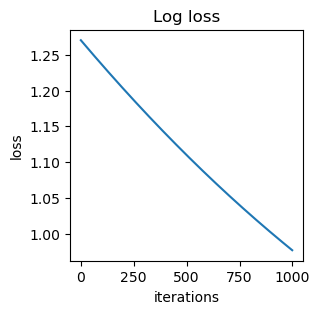

In [208]:
evaluator.show_errors(logistic_regression.errors)

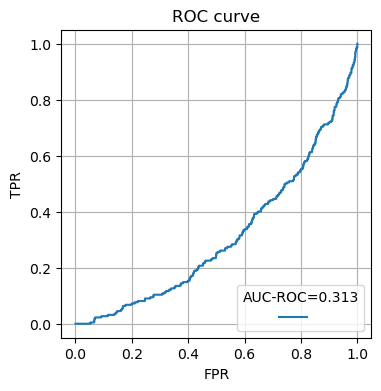

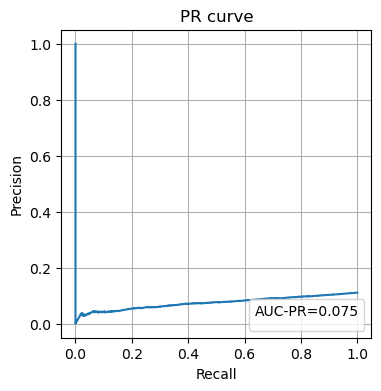

In [209]:
ROC_AUC, PR_AUC = evaluator.evaluation()